In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
df = pd.read_csv ("/content/drive/MyDrive/Colab Notebooks/laptop_pricing.csv")
df

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
...,...,...,...,...,...,...,...,...,...,...,...,...
233,Lenovo,4,IPS Panel,2,1,7,35.560,2.6,8,256,1.70,1891
234,Toshiba,3,Full HD,2,1,5,33.782,2.4,8,256,1.20,1950
235,Lenovo,4,IPS Panel,2,1,5,30.480,2.6,8,256,1.36,2236
236,Lenovo,3,Full HD,3,1,5,39.624,2.5,6,256,2.40,883


In [41]:
df = df[["Manufacturer", "Screen_Size_cm", "Price"]]
df

,Manufacturer,Screen_Size_cm,Price
0,Acer,35.560,978
1,Dell,39.624,634
2,Dell,39.624,946
3,Dell,33.782,1244
4,HP,39.624,837
...,...,...,...
233,Lenovo,35.560,1891
234,Toshiba,33.782,1950
235,Lenovo,30.480,2236
236,Lenovo,39.624,883


In [42]:
# 1. Moda Manufacturer

df['Manufacturer'].value_counts().idxmax()

'Dell'

In [43]:
# 1. Medidas Screen Size

print('Moda: ', df['Screen_Size_cm'].value_counts().idxmax())
print('Média : ',df['Screen_Size_cm'].mean())
print('Mediana: ',df['Screen_Size_cm'].median())
print('Mínimo: ',df['Screen_Size_cm'].min())
print('Máximo: ',df['Screen_Size_cm'].max())

print('Q1: ',df['Screen_Size_cm'].quantile(0.25))
print('Q3: ',df['Screen_Size_cm'].quantile(0.75))

print('IQR:', df['Screen_Size_cm'].quantile(0.75)-df['Screen_Size_cm'].quantile(0.25))

print('IQR (Amplitude Interquartil):', iqr)
print('Desvio Padão: ', df['Screen_Size_cm'].std())
amplitude = df['Screen_Size_cm'].max() - df['Screen_Size_cm'].min()
print('Amplitude Total: ', amplitude)
print('Skew: ',df['Screen_Size_cm'].skew())

Moda:  39.624
Média :  37.26961538461539
Mediana:  38.1
Mínimo:  30.48
Máximo:  43.942
Q1:  35.56
Q3:  39.624
IQR: 4.064
IQR (Amplitude Interquartil): 4.064
Desvio Padão:  2.971365242625714
Amplitude Total:  13.462
Skew:  -0.030994006487070746


In [44]:
# 1. Medidas Price

print('Moda: ', df['Price'].value_counts().idxmax())
print('Média : ',df['Price'].mean())
print('Mediana: ',df['Price'].median())
print('Mínimo: ',df['Price'].min())
print('Máximo: ',df['Price'].max())
print('Q1: ',df['Price'].quantile(0.25))
print('Q3: ',df['Price'].quantile(0.75))
print('IQR:', df['Price'].quantile(0.75)-df['Price'].quantile(0.25))

print('Desvio Padão: ', df['Price'].std())
amplitude = df['Price'].max() - df['Price'].min()
print('Amplitude Total: ', amplitude)
print('Skew: ',df['Price'].skew())

Moda:  1117
Média :  1462.3445378151262
Mediana:  1333.0
Mínimo:  527
Máximo:  3810
Q1:  1066.5
Q3:  1777.0
IQR: 710.5
Desvio Padão:  574.6076986737145
Amplitude Total:  3283
Skew:  1.273529677114741


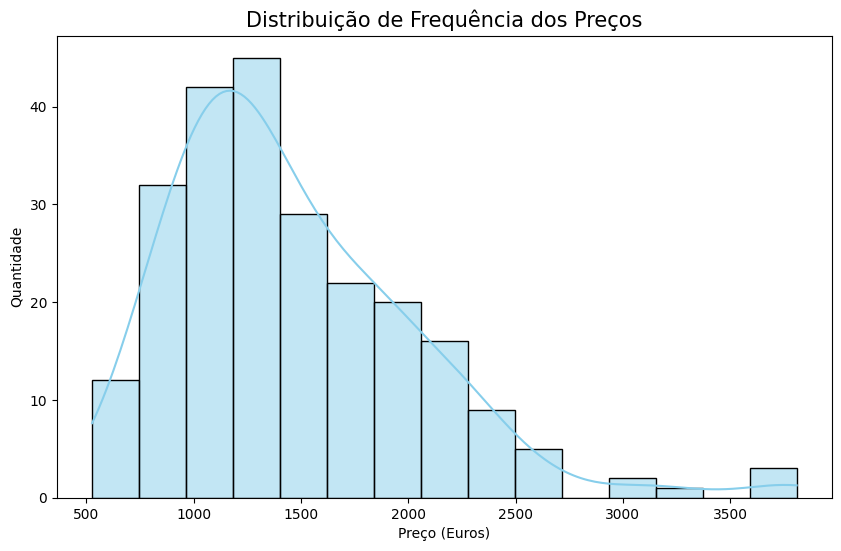

In [54]:
#Price

plt.figure(figsize=(10, 6))

sns.histplot(df['Price'], bins=15, kde=True, color='skyblue')

plt.title('Distribuição de Frequência dos Preços', fontsize=15)
plt.xlabel('Preço (Euros)')
plt.ylabel('Quantidade')

plt.show()

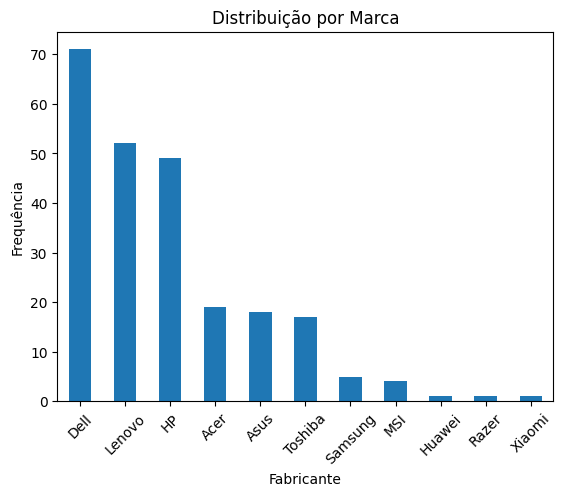

In [59]:
#Manufacturer
df['Manufacturer'].value_counts().plot(kind='bar')
plt.title('Distribuição por Marca')
plt.xlabel('Fabricante')
plt.ylabel('Frequência')
plt.xticks(rotation=45)
plt.show()

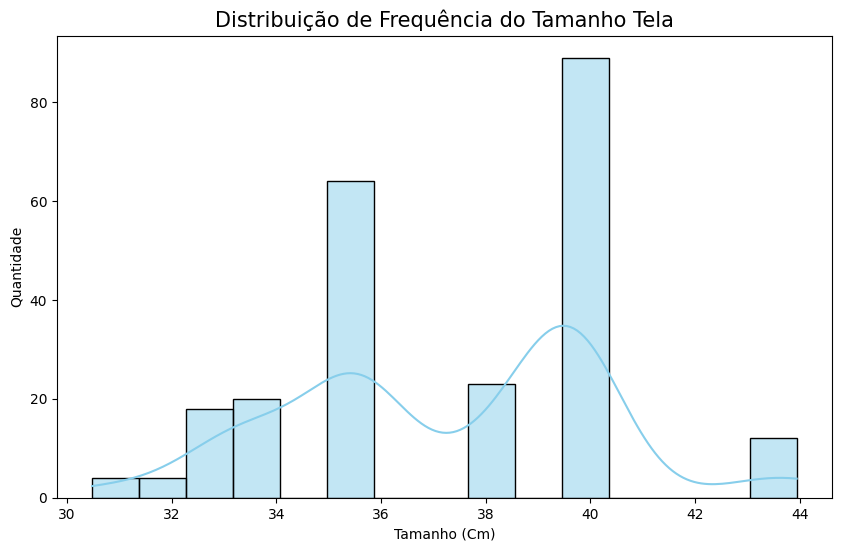

In [52]:
#Screen Size

plt.figure(figsize=(10, 6))

sns.histplot(df['Screen_Size_cm'], bins=15, kde=True, color='skyblue')

plt.title('Distribuição de Frequência do Tamanho Tela', fontsize=15)
plt.xlabel('Tamanho (Cm)')
plt.ylabel('Quantidade')

plt.show()

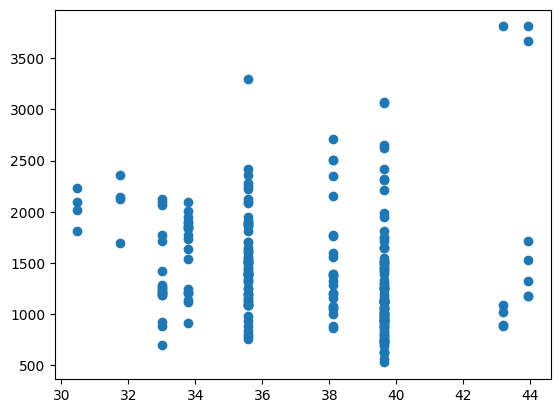

In [55]:
# Correlação entre Screen size e Price
plt.scatter(df['Screen_Size_cm'], df['Price'])

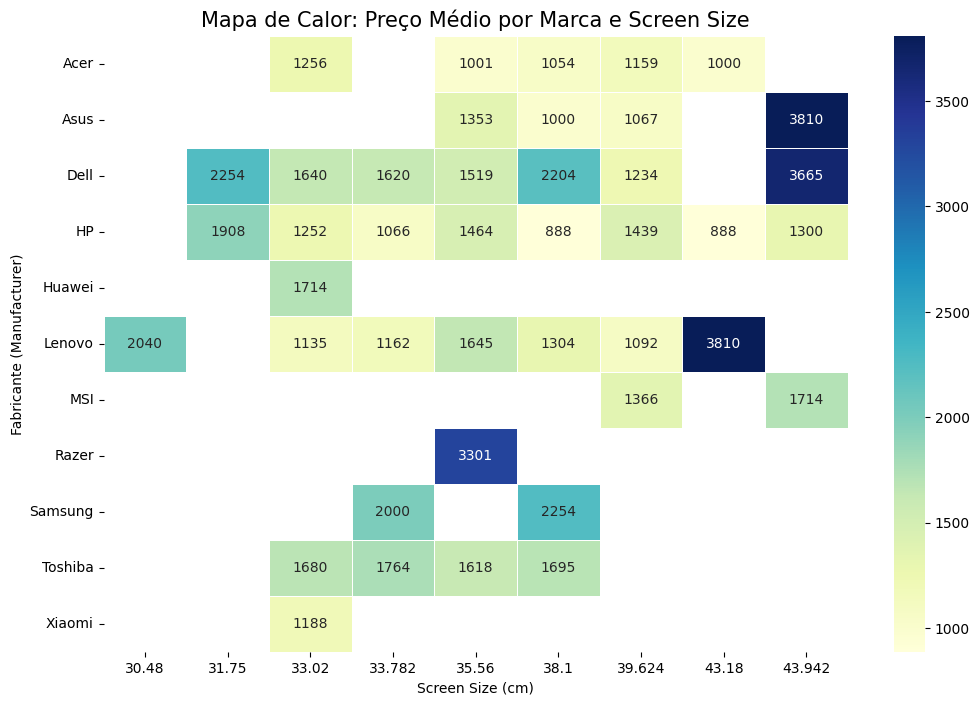

In [63]:
pivot_table = df.pivot_table(index='Manufacturer',
                             columns='Screen_Size_cm',
                             values='Price',
                             aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=.5)

plt.title('Mapa de Calor: Preço Médio por Marca e Screen Size', fontsize=15)
plt.xlabel('Screen Size (cm)')
plt.ylabel('Fabricante (Manufacturer)')

plt.show()

Entre Price e Screen size não há uma correlação linear.
No caso do Manufacturer, por se tratar de uma variável qualitativa  nominal, não é possível analisar uma relação linear, mas sim comparar a distribuição dos preços entre diferentes fabricantes.